# 06 Tree Preprocessing V2 Ablation

This notebook is the follow-up to the earlier tree-model comparison.

The earlier notebook answered the broad model question. This one answers the next question:
after choosing `XGBoost` as the main tree learner, which preprocessing pieces actually help it?

It focuses on the newer
`scripts/run_tree_ablation_v2.py` and `src/fraud_detection/tree_preprocessing_v2.py`
workflow and asks:

1. What exactly does `tree_preprocessing_v2` add?
2. Which preprocessing blocks actually improve `XGBoost`?
3. Is the gain coming more from missingness signals or from group-level amount features?


## Link To The Earlier Model Comparison

The earlier comparison already did the broad model-selection job, so we only keep the parts that matter for the handoff:

- `baseline logistic regression` is still useful because it is the easiest benchmark to explain
- `XGBoost` is the natural model to study further because it performed best and can absorb richer fraud-oriented features

This notebook therefore does two things in sequence:

1. briefly summarize what the earlier tree-model notebook already established about tree families
2. compare the earlier `XGBoost` and `baseline` references against the newer `v2` preprocessing variants


## Why This Version Is Cleaner

This notebook uses a single model family throughout: `XGBoost`.

That makes the ablation easier to read because every difference in performance now comes from
preprocessing choices rather than model choice. The three variants are:

- `v2_core`: base engineered features plus count encoding
- `v2_plus_missing_flags`: `v2_core` plus missing-indicator columns
- `v2_full`: `v2_plus_missing_flags` plus group-level amount deviation features


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.eda import set_plot_theme
from src.fraud_detection.data_prep_safe import load_merged_data_safe, make_time_validation_split
from src.fraud_detection.train import fit_baseline_experiment
from src.fraud_detection.tree_preprocessing_v2 import (
    EXTRA_COUNT_ENCODE_COLS,
    GROUP_AMOUNT_COLS,
    fit_tree_preprocessor_v2,
    transform_tree_preprocessor_v2,
)
from src.fraud_detection.tree_models import fit_tree_model_benchmark

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

NROWS = None
RANDOM_STATE = 42
OUTPUT_PATH = PROJECT_ROOT / "outputs" / "tree_ablation_v2_results.json"
SAMPLE_SIZE = 80_000


In [2]:
def top_k_metrics(y_true, y_score, frac=0.05):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    k = max(1, int(len(y_true) * frac))
    idx = np.argsort(-y_score)[:k]

    precision_at_k = y_true[idx].mean()
    recall_at_k = y_true[idx].sum() / max(1, y_true.sum())
    return precision_at_k, recall_at_k


def build_topk_summary(y_true, y_score, label, fracs=(0.01, 0.03, 0.05, 0.10)):
    rows = []
    for frac in fracs:
        precision_at_k, recall_at_k = top_k_metrics(y_true, y_score, frac=frac)
        rows.append(
            {
                "model": label,
                "top_pct": f"{int(frac * 100)}%",
                "precision": float(precision_at_k),
                "recall": float(recall_at_k),
            }
        )
    return rows


def evaluate_variant(train_part, valid_part, name, add_missing_indicators, add_group_amount_features):
    artifacts = fit_tree_preprocessor_v2(
        train_part,
        add_missing_indicators=add_missing_indicators,
        add_group_amount_features=add_group_amount_features,
        drop_missing_threshold=0.999,
    )

    X_train = transform_tree_preprocessor_v2(train_part, artifacts, impute_numeric=False)
    X_valid = transform_tree_preprocessor_v2(valid_part, artifacts, impute_numeric=False)

    y_train = train_part["isFraud"].to_numpy()
    y_valid = valid_part["isFraud"].to_numpy()

    model = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    valid_proba = model.predict_proba(X_valid)[:, 1]

    precision_at_5, recall_at_5 = top_k_metrics(y_valid, valid_proba, frac=0.05)
    topk_rows = build_topk_summary(y_valid, valid_proba, name)

    artifact_summary = {
        "variant": name,
        "drop_cols": len(artifacts.drop_cols),
        "object_cols_dropped_after_encoding": len(artifacts.object_cols_to_drop),
        "count_encoded_columns": len(artifacts.count_encode_cols),
        "missing_indicator_columns": len(artifacts.missing_indicator_cols),
        "group_amount_base_columns": len(artifacts.group_amount_maps),
        "estimated_group_amount_features": int(len(artifacts.group_amount_maps) * 3),
        "final_feature_count": len(artifacts.feature_columns),
        "uses_missing_flags": artifacts.add_missing_indicators,
        "uses_group_amount_features": artifacts.add_group_amount_features,
    }

    metric_row = {
        "variant": name,
        "roc_auc": float(roc_auc_score(y_valid, valid_proba)),
        "average_precision": float(average_precision_score(y_valid, valid_proba)),
        "precision_at_top_5pct": float(precision_at_5),
        "recall_at_top_5pct": float(recall_at_5),
        "n_features": int(X_train.shape[1]),
    }
    variant_artifacts = {
        "valid_proba": valid_proba,
        "y_valid": y_valid,
    }
    return metric_row, artifact_summary, topk_rows, variant_artifacts


In [3]:
baseline_experiment = fit_baseline_experiment(
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    missing_threshold=0.95,
)

tree_benchmark = fit_tree_model_benchmark(
    sample_size=SAMPLE_SIZE,
    valid_fraction=0.20,
    random_state=RANDOM_STATE,
    missing_threshold=0.98,
)

train_df, _ = load_merged_data_safe(nrows=NROWS)
train_part, valid_part = make_time_validation_split(train_df)

metric_rows = []
artifact_rows = []
v2_topk_rows = []
variant_outputs = {}

variant_specs = [
    ("v2_core", False, False),
    ("v2_plus_missing_flags", True, False),
    ("v2_full", True, True),
]

for name, add_missing_indicators, add_group_amount_features in variant_specs:
    metric_row, artifact_row, topk_rows, variant_output = evaluate_variant(
        train_part,
        valid_part,
        name=name,
        add_missing_indicators=add_missing_indicators,
        add_group_amount_features=add_group_amount_features,
    )
    metric_rows.append(metric_row)
    artifact_rows.append(artifact_row)
    v2_topk_rows.extend(topk_rows)
    variant_outputs[name] = variant_output

results = pd.DataFrame(metric_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
artifact_summary = pd.DataFrame(artifact_rows)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(metric_rows, indent=2), encoding="utf-8")

best_row = results.iloc[0]
core_row = results.loc[results["variant"] == "v2_core"].iloc[0]
full_row = results.loc[results["variant"] == "v2_full"].iloc[0]
flag_row = results.loc[results["variant"] == "v2_plus_missing_flags"].iloc[0]

display(results.style.hide(axis="index"))


variant,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct,n_features
v2_plus_missing_flags,0.914340,0.552034,0.416427,0.605069,792
v2_core,0.913423,0.550732,0.413548,0.600886,462
v2_full,0.911789,0.553101,0.412024,0.598671,807


## What The Earlier Tree Notebook Already Showed

The earlier `03_tree_models.ipynb` established a useful pattern across model families:

- boosted trees such as `XGBoost`, `LightGBM`, and `CatBoost` are the strongest models overall
- bagged trees such as `RandomForest` and `ExtraTrees` are competitive but usually weaker
- the linear model is the easiest baseline to explain, but it cannot use the engineered interactions as effectively

The practical takeaway is that fraud detection in this project depends heavily on non-linear feature interactions, identity-style combinations, and ranking difficult edge cases near the top of the score distribution. That is exactly the setting where boosted trees tend to beat simpler baselines.


In [4]:
earlier_tree_view = tree_benchmark["comparison"][
    ["model", "family", "roc_auc", "average_precision", "precision_at_top_5pct", "recall_at_top_5pct"]
].copy()

tree_focus_order = [
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "HistGradientBoosting",
    "RandomForest",
    "ExtraTrees",
    "LogisticRegression",
    "TreeEnsembleMean",
]
earlier_tree_view = earlier_tree_view[
    earlier_tree_view["model"].isin(tree_focus_order)
].copy()
earlier_tree_view["model"] = pd.Categorical(
    earlier_tree_view["model"],
    categories=tree_focus_order,
    ordered=True,
)
earlier_tree_view = earlier_tree_view.sort_values("model").reset_index(drop=True)

display(earlier_tree_view.style.hide(axis="index"))


model,family,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct
XGBoost,tree_model,0.891564,0.478056,0.378750,0.530648
LightGBM,tree_model,0.883162,0.477861,0.372500,0.521891
CatBoost,tree_model,0.880355,0.447838,0.365000,0.511384
HistGradientBoosting,tree_model,0.879225,0.459722,0.357500,0.500876
RandomForest,tree_model,0.867144,0.404834,0.347500,0.486865
ExtraTrees,tree_model,0.850512,0.375915,0.320000,0.448336
LogisticRegression,linear_baseline,0.828903,0.323877,0.320000,0.448336
TreeEnsembleMean,ensemble,0.887621,0.475222,0.373750,0.523643


## Earlier Tree Model Comparison


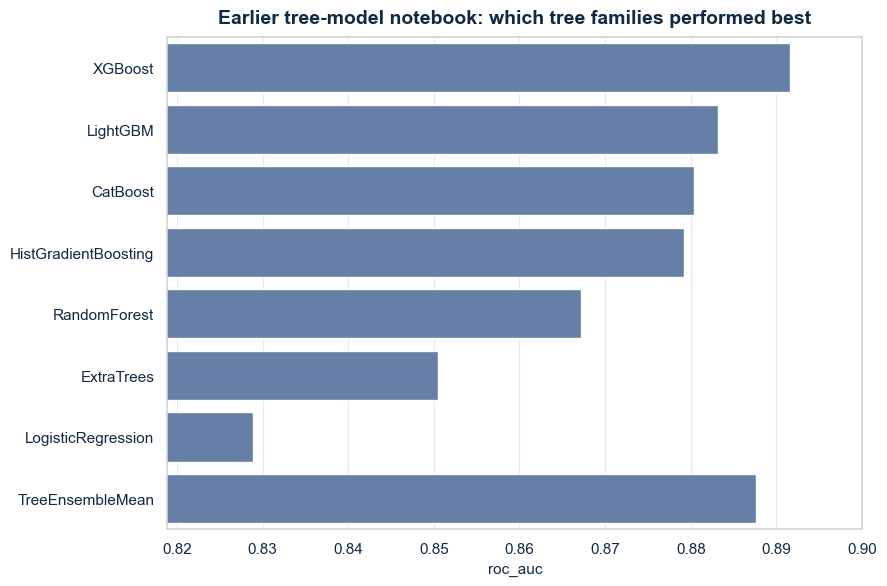

In [5]:
earlier_tree_plot = earlier_tree_view.copy().sort_values("roc_auc", ascending=True)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=earlier_tree_plot,
    x="roc_auc",
    y="model",
    color="#5B7DB1",
)
plt.title("Earlier tree-model notebook: which tree families performed best")
plt.xlabel("roc_auc")
plt.ylabel("")
plt.xlim(max(0.80, earlier_tree_plot["roc_auc"].min() - 0.01), 0.90)
plt.tight_layout()
plt.show()


## What `tree_preprocessing_v2` Does

The `v2` preprocessor is still tree-oriented, but it is more explicit and modular than the earlier notebook pipeline.

It adds:

- time features from `TransactionDT`
- amount features such as `TransactionAmt_log1p` and `TransactionAmt_cents`
- email prefix and suffix tokens
- simple device / OS / browser tokens
- binary versions of the `M1` to `M9` columns
- `uid1`, `uid2`, and `uid3` identity-style combinations
- count encoding for string-like and selected id-like columns
- optional missing indicators
- optional group-level amount deviation features

It also intentionally keeps numeric `NaN` values for `XGBoost` instead of forcing median imputation.


In [6]:
method_table = pd.DataFrame(
    [
        {
            "block": "base feature engineering",
            "what_it_adds": "time, amount, email, device/browser/os tokens, M-bin flags, uid1/uid2/uid3",
            "why_it_matters": "creates non-linear signals that trees can split on directly",
        },
        {
            "block": "count encoding",
            "what_it_adds": ", ".join(EXTRA_COUNT_ENCODE_COLS[:8]) + ", ...",
            "why_it_matters": "compresses high-cardinality identity-like columns into dense numeric signals",
        },
        {
            "block": "missing indicators",
            "what_it_adds": "binary flags for columns with 5% to 99.9% missingness",
            "why_it_matters": "lets XGBoost use missingness as signal rather than noise",
        },
        {
            "block": "group amount features",
            "what_it_adds": ", ".join(GROUP_AMOUNT_COLS),
            "why_it_matters": "measures whether a transaction amount looks unusual relative to card or uid group history",
        },
    ]
)

display(method_table.style.hide(axis="index"))
display(artifact_summary.style.hide(axis="index"))


block,what_it_adds,why_it_matters
base feature engineering,"time, amount, email, device/browser/os tokens, M-bin flags, uid1/uid2/uid3",creates non-linear signals that trees can split on directly
count encoding,"ProductCD, card1, card2, card3, card5, addr1, addr2, P_emaildomain, ...",compresses high-cardinality identity-like columns into dense numeric signals
missing indicators,binary flags for columns with 5% to 99.9% missingness,lets XGBoost use missingness as signal rather than noise
group amount features,"card1, card4, addr1, uid1, uid2",measures whether a transaction amount looks unusual relative to card or uid group history


variant,drop_cols,object_cols_dropped_after_encoding,count_encoded_columns,missing_indicator_columns,group_amount_base_columns,estimated_group_amount_features,final_feature_count,uses_missing_flags,uses_group_amount_features
v2_core,1,41,47,0,0,0,462,False,False
v2_plus_missing_flags,1,41,47,330,0,0,792,True,False
v2_full,1,41,47,330,5,15,807,True,True


## Bridge To The New Comparison

The next comparison keeps two anchors from the earlier analysis:

- the earlier `baseline` as the simplest benchmark
- the earlier `XGBoost` as the strongest pre-`v2` tree pipeline

Then it places the three new `v2` variants beside them. This makes the question more concrete:
does the newer preprocessing beat the simple baseline, and how close does it get to the earlier strongest `XGBoost` setup?


In [7]:
baseline_metrics = baseline_experiment["metrics"]
earlier_xgb = tree_benchmark["comparison"].loc[
    tree_benchmark["comparison"]["model"] == "XGBoost"
].iloc[0]

bridge_rows = [
    {
        "model": "BaselineLogistic",
        "group": "earlier_reference",
        "roc_auc": float(baseline_metrics["roc_auc"]),
        "average_precision": float(baseline_metrics["average_precision"]),
        "precision_at_top_5pct": float(baseline_metrics["precision_at_top_5pct"]),
        "recall_at_top_5pct": float(baseline_metrics["recall_at_top_5pct"]),
    },
    {
        "model": "EarlierXGBoost",
        "group": "earlier_reference",
        "roc_auc": float(earlier_xgb["roc_auc"]),
        "average_precision": float(earlier_xgb["average_precision"]),
        "precision_at_top_5pct": float(earlier_xgb["precision_at_top_5pct"]),
        "recall_at_top_5pct": float(earlier_xgb["recall_at_top_5pct"]),
    },
]

for row in metric_rows:
    bridge_rows.append(
        {
            "model": row["variant"],
            "group": "v2_ablation",
            "roc_auc": row["roc_auc"],
            "average_precision": row["average_precision"],
            "precision_at_top_5pct": row["precision_at_top_5pct"],
            "recall_at_top_5pct": row["recall_at_top_5pct"],
        }
    )

bridge_comparison = pd.DataFrame(bridge_rows)
display(bridge_comparison.style.hide(axis="index"))


model,group,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct
BaselineLogistic,earlier_reference,0.872774,0.450258,0.362500,0.509666
EarlierXGBoost,earlier_reference,0.891564,0.478056,0.378750,0.530648
v2_core,v2_ablation,0.913423,0.550732,0.413548,0.600886
v2_plus_missing_flags,v2_ablation,0.914340,0.552034,0.416427,0.605069
v2_full,v2_ablation,0.911789,0.553101,0.412024,0.598671


## Focused Comparison Plots


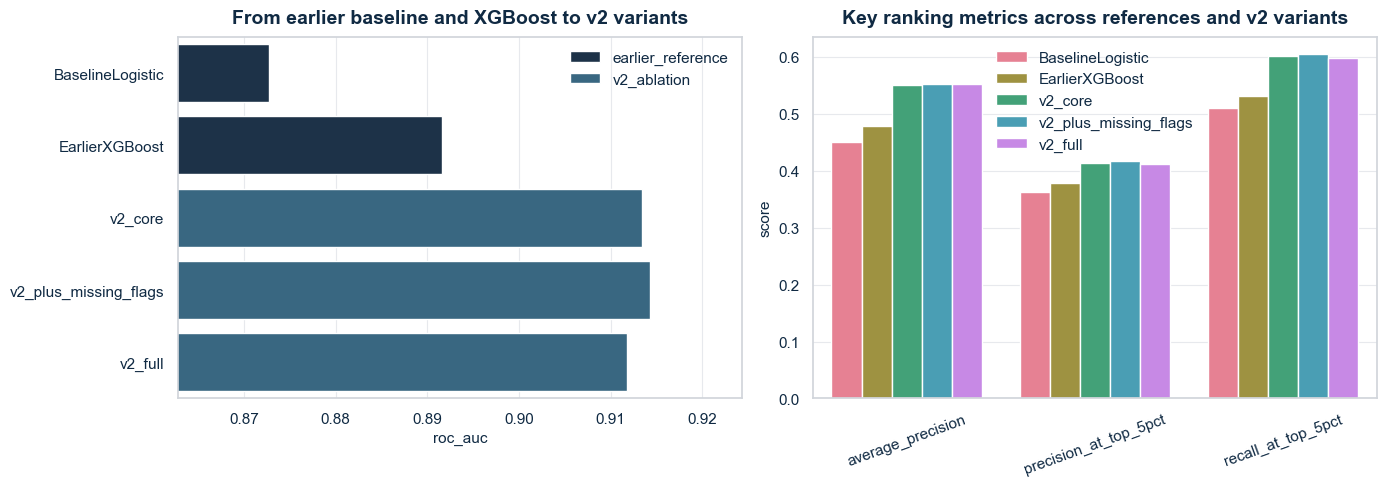

In [8]:
plot_results = bridge_comparison.copy()
plot_order = ["BaselineLogistic", "EarlierXGBoost", "v2_core", "v2_plus_missing_flags", "v2_full"]
plot_results["model"] = pd.Categorical(plot_results["model"], categories=plot_order, ordered=True)
plot_results = plot_results.sort_values("model")

metric_plot = plot_results.melt(
    id_vars=["model", "group"],
    value_vars=["average_precision", "precision_at_top_5pct", "recall_at_top_5pct"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_results,
    x="roc_auc",
    y="model",
    hue="group",
    ax=axes[0],
)
axes[0].set_title("From earlier baseline and XGBoost to v2 variants")
axes[0].set_xlabel("roc_auc")
axes[0].set_ylabel("")
axes[0].set_xlim(
    max(0.5, plot_results["roc_auc"].min() - 0.01),
    min(1.0, plot_results["roc_auc"].max() + 0.01),
)
axes[0].legend(title="")

sns.barplot(
    data=metric_plot,
    x="metric",
    y="value",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Key ranking metrics across references and v2 variants")
axes[1].set_xlabel("")
axes[1].set_ylabel("score")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="")

plt.tight_layout()
plt.show()


## Top 1%, 3%, 5%, And 10% Checks

`average precision` and `precision@top_5%` are not the same kind of metric.

- `average precision` summarizes the full precision-recall ranking curve
- `precision@top_k%` only looks at a narrow slice near the top of the ranked list

So if they do not line up perfectly, that is not necessarily a contradiction. The table below makes that easier to inspect directly by checking several top-risk cutoffs.


model,top_pct,precision,recall
BaselineLogistic,1%,0.762500,0.214411
BaselineLogistic,3%,0.481250,0.405975
BaselineLogistic,5%,0.362500,0.509666
BaselineLogistic,10%,0.226875,0.637961
EarlierXGBoost,1%,0.850000,0.238179
EarlierXGBoost,3%,0.510417,0.429072
EarlierXGBoost,5%,0.378750,0.530648
EarlierXGBoost,10%,0.239375,0.670753
v2_core,1%,0.883997,0.256890
v2_core,3%,0.572114,0.498770


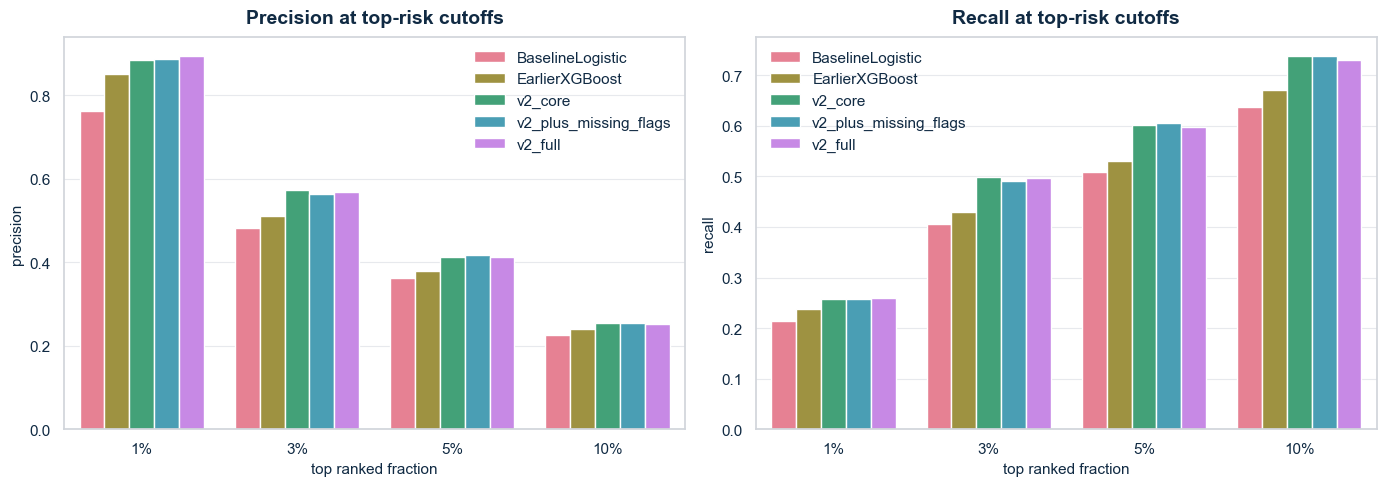

In [9]:
baseline_topk = build_topk_summary(
    baseline_experiment["y_valid"].to_numpy(),
    baseline_experiment["validation_scores"],
    "BaselineLogistic",
)

earlier_xgb_topk = build_topk_summary(
    np.asarray(tree_benchmark["y_valid"]),
    tree_benchmark["prediction_frame"]["XGBoost"].to_numpy(),
    "EarlierXGBoost",
)

topk_comparison = pd.DataFrame(baseline_topk + earlier_xgb_topk + v2_topk_rows)
topk_comparison["model"] = pd.Categorical(
    topk_comparison["model"],
    categories=["BaselineLogistic", "EarlierXGBoost", "v2_core", "v2_plus_missing_flags", "v2_full"],
    ordered=True,
)
topk_comparison["top_pct"] = pd.Categorical(
    topk_comparison["top_pct"],
    categories=["1%", "3%", "5%", "10%"],
    ordered=True,
)
topk_comparison = topk_comparison.sort_values(["model", "top_pct"]).reset_index(drop=True)

display(topk_comparison.style.hide(axis="index"))

topk_plot = topk_comparison.melt(
    id_vars=["model", "top_pct"],
    value_vars=["precision", "recall"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

sns.barplot(
    data=topk_plot.loc[topk_plot["metric"] == "precision"],
    x="top_pct",
    y="value",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Precision at top-risk cutoffs")
axes[0].set_xlabel("top ranked fraction")
axes[0].set_ylabel("precision")
axes[0].legend(title="")

sns.barplot(
    data=topk_plot.loc[topk_plot["metric"] == "recall"],
    x="top_pct",
    y="value",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Recall at top-risk cutoffs")
axes[1].set_xlabel("top ranked fraction")
axes[1].set_ylabel("recall")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


## Reading The Results

There are two layers to read together.

First, the earlier tree-model comparison shows that boosted trees are the strongest model family in this project. That is why `XGBoost` becomes the main model to study further, while the logistic baseline stays in the story as the simplest reference point.

Second, the `v2` ablation shows what happens after the model choice is already fixed. Here the question is no longer "which model family wins?" but "which preprocessing components make the chosen `XGBoost` pipeline stronger?"

The most useful comparison is therefore not the full old leaderboard. It is the bridge from:

- `BaselineLogistic`, which tells us what a simple benchmark can do
- `EarlierXGBoost`, which shows the stronger pre-`v2` tree setup
- `v2_core`, `v2_plus_missing_flags`, and `v2_full`, which isolate what the newer preprocessing adds step by step

This gives the report a cleaner flow: first justify why `XGBoost` is the right family to focus on, then show how preprocessing choices inside that family change the final ranking performance.


## Reporting Guidance

A concise way to write this up in the report:

- Start with the earlier result that boosted trees outperform the simpler baseline and that `XGBoost` is the strongest tree learner to carry forward.
- Then explain that `v2` is not a new model-family contest. It is a preprocessing ablation inside the chosen `XGBoost` pipeline.
- Use the bridge comparison to show how far `v2` moves beyond the baseline and how close it gets to the earlier `XGBoost` reference.
- Keep the visuals selective. One plot for the earlier tree-family judgment and one compact bridge plot for `baseline`, earlier `XGBoost`, and the three `v2` variants is enough.


## Confusion Matrix And Threshold Review For The Best `v2` Variant

This final view shows the confusion matrix for the best `v2` preprocessing variant using the default probability threshold of `0.5`.

To match the fraud-review business view, class `1` means `fraud` and the matrix is ordered with `TP` in the top-left corner.

A compact threshold sweep is also included so we can compare how the baseline behaves as the fraud threshold becomes stricter.


item,value
best_variant,v2_plus_missing_flags
positive_class,1 = fraud
threshold,0.500000
true_negative,113656
false_positive,388
false_negative,2586
true_positive,1478


threshold,true_positive,false_negative,false_positive,true_negative,recall,precision,false_positive_rate,predicted_fraud_rate
0.500000,1478,2586,388,113656,0.363681,0.792069,0.003402,0.015799


,pred_fraud_1,pred_nonfraud_0
actual_fraud_1,1478,2586
actual_nonfraud_0,388,113656


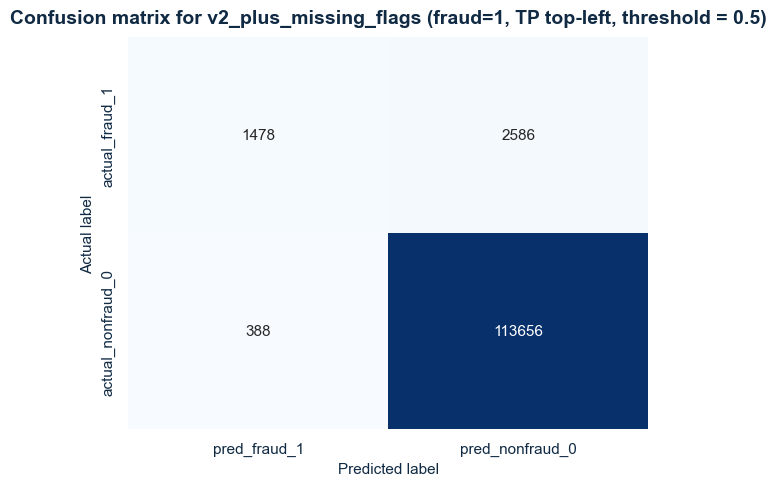

,threshold,true_positive,false_negative,false_positive,true_negative,recall,precision,false_positive_rate,predicted_fraud_rate
0,0.5000,1478,2586,388,113656,0.3637,0.7921,0.0034,0.0158
1,0.5500,1403,2661,302,113742,0.3452,0.8229,0.0026,0.0144
2,0.6000,1332,2732,252,113792,0.3278,0.8409,0.0022,0.0134
3,0.6500,1263,2801,215,113829,0.3108,0.8545,0.0019,0.0125
4,0.7000,1191,2873,172,113872,0.2931,0.8738,0.0015,0.0115
5,0.7500,1100,2964,153,113891,0.2707,0.8779,0.0013,0.0106


In [10]:
best_variant_name = best_row["variant"]
best_variant_output = variant_outputs[best_variant_name]
best_valid_scores = pd.Series(best_variant_output["valid_proba"])
best_y_valid = pd.Series(best_variant_output["y_valid"])

def summarize_threshold(scores, y_true, threshold):
    pred = (scores >= threshold).astype(int)
    tn = int(((y_true == 0) & (pred == 0)).sum())
    fp = int(((y_true == 0) & (pred == 1)).sum())
    fn = int(((y_true == 1) & (pred == 0)).sum())
    tp = int(((y_true == 1) & (pred == 1)).sum())
    return {
        "threshold": float(threshold),
        "true_positive": tp,
        "false_negative": fn,
        "false_positive": fp,
        "true_negative": tn,
        "recall": tp / (tp + fn) if (tp + fn) else 0.0,
        "precision": tp / (tp + fp) if (tp + fp) else 0.0,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) else 0.0,
        "predicted_fraud_rate": pred.mean(),
    }

base_summary = summarize_threshold(best_valid_scores, best_y_valid, threshold=0.5)
confusion_frame = pd.DataFrame(
    [[base_summary["true_positive"], base_summary["false_negative"]], [base_summary["false_positive"], base_summary["true_negative"]]],
    index=["actual_fraud_1", "actual_nonfraud_0"],
    columns=["pred_fraud_1", "pred_nonfraud_0"],
)

display(
    pd.DataFrame(
        [
            {"item": "best_variant", "value": best_variant_name},
            {"item": "positive_class", "value": "1 = fraud"},
            {"item": "threshold", "value": 0.5},
            {"item": "true_negative", "value": base_summary["true_negative"]},
            {"item": "false_positive", "value": base_summary["false_positive"]},
            {"item": "false_negative", "value": base_summary["false_negative"]},
            {"item": "true_positive", "value": base_summary["true_positive"]},
        ]
    ).style.hide(axis="index")
)

business_summary = pd.DataFrame([base_summary])[
    [
        "threshold",
        "true_positive",
        "false_negative",
        "false_positive",
        "true_negative",
        "recall",
        "precision",
        "false_positive_rate",
        "predicted_fraud_rate",
    ]
]
display(business_summary.style.hide(axis="index"))
display(confusion_frame)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_frame, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion matrix for {best_variant_name} (fraud=1, TP top-left, threshold = 0.5)")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

threshold_grid = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
threshold_review = pd.DataFrame(
    [summarize_threshold(best_valid_scores, best_y_valid, threshold=value) for value in threshold_grid]
)[
    [
        "threshold",
        "true_positive",
        "false_negative",
        "false_positive",
        "true_negative",
        "recall",
        "precision",
        "false_positive_rate",
        "predicted_fraud_rate",
    ]
]
display(threshold_review)
